# Monte Carlo Simulation: Enterprise Risk Portfolio Modeling

**Course:** ALY 6130 - Risk Management Analytics  
**Group 4:** Adwoa Bempomaa, Sara Mathai, Lawrence Dass  
**Date:** March 2026

Implements Monte Carlo simulation (10,000 iterations, seed=42) across all 25 enterprise risks.
Two-stage Bernoulli-Triangular process per risk.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

SEED = 42
N = 10_000
rng = np.random.default_rng(SEED)
print(f'Configuration: {N:,} iterations, seed={SEED}')

Configuration: 10,000 iterations, seed=42


## 1. Simulation Parameters (All 25 Risks)

In [7]:
# Parameters: (risk_id, probability, low_m, mode_m, high_m, sign)
params = [
    ('R3',  0.90, 60.0,  250.0, 350.0, +1),
    ('R19', 0.70, 30.0,  120.0, 200.0, +1),
    ('R20', 0.70, 25.0,  100.0, 180.0, +1),
    ('R2',  0.70, 40.0,  120.0, 200.0, -1),
    ('R1',  0.70, 30.0,  100.0, 150.0, -1),
    ('R13', 0.70, 25.0,   80.0, 130.0, -1),
    ('R17', 0.70, 20.0,   75.0, 120.0, -1),
    ('R23', 0.50, 20.0,   80.0, 150.0, -1),
    ('R15', 0.70, 10.0,   40.0,  80.0, -1),
    ('R5',  0.50, 50.0,  150.0, 250.0, -1),
    ('R6',  0.50,  5.0,   20.0,  40.0, -1),
    ('R7',  0.50,  5.0,   20.0,  40.0, -1),
    ('R8',  0.50,  5.0,   18.0,  35.0, -1),
    ('R9',  0.50,  5.0,   18.0,  35.0, -1),
    ('R10', 0.50,  3.0,   12.0,  25.0, -1),
    ('R11', 0.50,  3.0,   12.0,  25.0, -1),
    ('R12', 0.50,  5.0,   20.0,  40.0, -1),
    ('R14', 0.50,  3.0,   12.0,  25.0, -1),
    ('R16', 0.50,  5.0,   20.0,  40.0, -1),
    ('R24', 0.50,  3.0,   12.0,  25.0, -1),
    ('R18', 0.50,  5.0,   20.0,  40.0, -1),
    ('R4',  0.50,  5.0,   18.0,  35.0, -1),
    ('R21', 0.30,  0.5,    2.0,   5.0, -1),
    ('R22', 0.30,  0.5,    1.5,   4.0, -1),
    ('R25', 0.30,  1.0,    5.0,  12.0, -1),
]

print(f'{"Risk":6s} {"P":>6s} {"Low":>8s} {"Mode":>8s} {"High":>8s} {"Dir":>6s}')
print('-'*50)
for rid, p, lo, mo, hi, sign in params:
    print(f'{rid:6s} {p:>6.0%} {lo:>8.1f} {mo:>8.1f} {hi:>8.1f} {"Up" if sign>0 else "Down":>6s}')

Risk        P      Low     Mode     High    Dir
--------------------------------------------------
R3        90%     60.0    250.0    350.0     Up
R19       70%     30.0    120.0    200.0     Up
R20       70%     25.0    100.0    180.0     Up
R2        70%     40.0    120.0    200.0   Down
R1        70%     30.0    100.0    150.0   Down
R13       70%     25.0     80.0    130.0   Down
R17       70%     20.0     75.0    120.0   Down
R23       50%     20.0     80.0    150.0   Down
R15       70%     10.0     40.0     80.0   Down
R5        50%     50.0    150.0    250.0   Down
R6        50%      5.0     20.0     40.0   Down
R7        50%      5.0     20.0     40.0   Down
R8        50%      5.0     18.0     35.0   Down
R9        50%      5.0     18.0     35.0   Down
R10       50%      3.0     12.0     25.0   Down
R11       50%      3.0     12.0     25.0   Down
R12       50%      5.0     20.0     40.0   Down
R14       50%      3.0     12.0     25.0   Down
R16       50%      5.0     20.0     4

## 2. Run Simulation

In [8]:
sim = {}
for rid, p, lo, mo, hi, sign in params:
    occ     = rng.binomial(1, p, N)
    impacts = rng.triangular(lo, mo, hi, N)
    sim[rid] = sign * occ * impacts

net = np.sum(np.column_stack(list(sim.values())), axis=1)

# LOCKED NUMBERS
mean_v = float(np.mean(net))
std_v  = float(np.std(net, ddof=1))
p05    = float(np.percentile(net, 5))
p95    = float(np.percentile(net, 95))
p_loss = float(np.mean(net < 0))
p_gain = float(np.mean(net >= 0))

print('NET PORTFOLIO RESULTS (LOCKED):')
print(f'  Mean:            ${mean_v:+,.1f}M')
print(f'  Std Deviation:   ${std_v:,.1f}M')
print(f'  5th Percentile:  ${p05:+,.1f}M')
print(f'  95th Percentile: ${p95:+,.1f}M')
print(f'  90% CI:          ${p05:+,.1f}M to ${p95:+,.1f}M')
print(f'  P(Net Loss):     {p_loss:.1%}')
print(f'  P(Net Gain):     {p_gain:.1%}')

NET PORTFOLIO RESULTS (LOCKED):
  Mean:            $-163.7M
  Std Deviation:   $182.7M
  5th Percentile:  $-470.5M
  95th Percentile: $+131.9M
  90% CI:          $-470.5M to $+131.9M
  P(Net Loss):     81.3%
  P(Net Gain):     18.7%


## 3. Net Portfolio Distribution

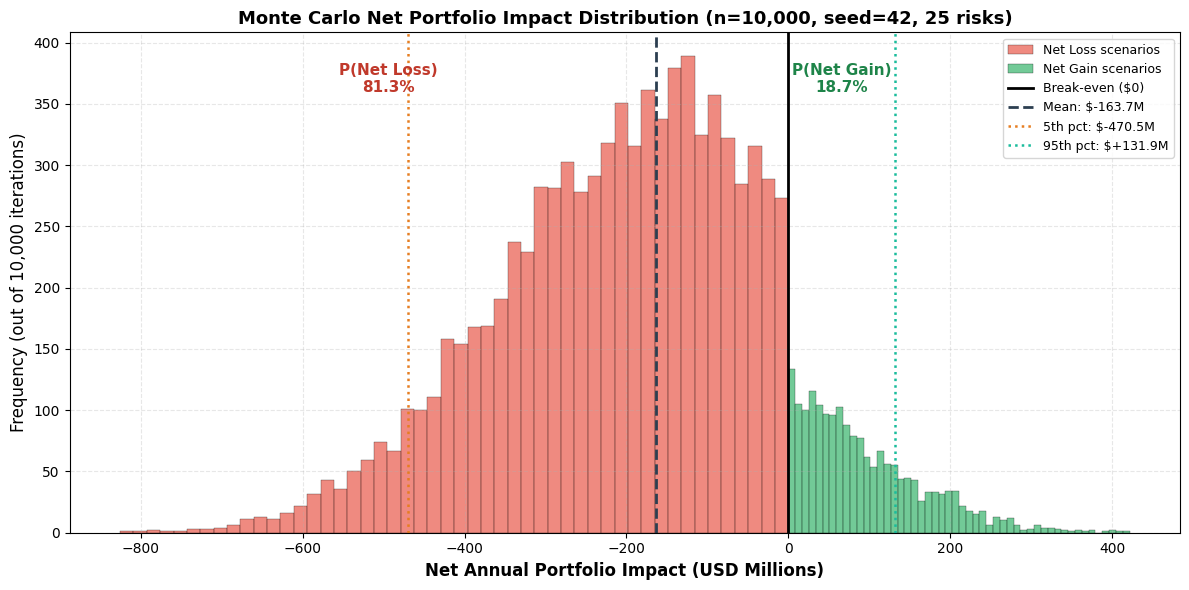

Saved: figure2_mc_net_distribution.png


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
n_neg = net[net < 0]
n_pos = net[net >= 0]
ax.hist(n_neg, bins=50, color='#E74C3C', alpha=0.65, edgecolor='black',
        linewidth=0.3, label='Net Loss scenarios')
ax.hist(n_pos, bins=50, color='#27AE60', alpha=0.65, edgecolor='black',
        linewidth=0.3, label='Net Gain scenarios')
ax.axvline(0, color='black', lw=2, linestyle='-', label='Break-even ($0)')
ax.axvline(mean_v, color='#2C3E50', lw=2, linestyle='--',
           label=f'Mean: ${mean_v:+,.1f}M')
ax.axvline(p05, color='#E67E22', lw=1.8, linestyle=':',
           label=f'5th pct: ${p05:+,.1f}M')
ax.axvline(p95, color='#1ABC9C', lw=1.8, linestyle=':',
           label=f'95th pct: ${p95:+,.1f}M')

ylim = ax.get_ylim()[1]
ax.text(p05 * 1.05, ylim * 0.88,
        f'P(Net Loss)\n{p_loss:.1%}', color='#C0392B',
        fontsize=11, fontweight='bold', ha='center')
ax.text(abs(p95) * 0.5, ylim * 0.88,
        f'P(Net Gain)\n{p_gain:.1%}', color='#1E8449',
        fontsize=11, fontweight='bold', ha='center')

ax.set_xlabel('Net Annual Portfolio Impact (USD Millions)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency (out of 10,000 iterations)', fontsize=12)
ax.set_title(f'Monte Carlo Net Portfolio Impact Distribution (n={N:,}, seed={SEED}, 25 risks)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('../report/figure2_mc_net_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: figure2_mc_net_distribution.png')

## 4. Category Portfolio Breakdown

In [10]:
cat_map = {
    'Regulatory':  ['R3','R23','R15','R14'],
    'Market':      ['R19','R20','R18','R22'],
    'Strategic':   ['R2','R1','R13','R17','R4'],
    'Financial':   ['R5','R16'],
    'Operational': ['R6','R8','R9','R11','R21'],
    'Technical':   ['R7','R10','R12','R24','R25'],
}

print(f'{"Category":15s} {"Mean ($M)":>12s} {"P05 ($M)":>12s} {"P95 ($M)":>12s} {"P(Loss)":>10s}')
print('-'*65)
cat_results = {}
for cat, ids in cat_map.items():
    arr = np.sum(np.column_stack([sim[i] for i in ids]), axis=1)
    cat_results[cat] = arr
    print(f'{cat:15s} {np.mean(arr):>+12.1f} {np.percentile(arr,5):>+12.1f} '
          f'{np.percentile(arr,95):>+12.1f} {np.mean(arr<0):>10.1%}')

Category           Mean ($M)     P05 ($M)     P95 ($M)    P(Loss)
-----------------------------------------------------------------
Regulatory            +119.9        -71.7       +262.9      13.4%
Market                +140.4         -2.1       +268.6       5.9%
Strategic             -265.0       -417.3        -98.1      99.7%
Financial              -84.5       -217.8         +0.0      74.5%
Operational            -37.7        -73.2         -2.0      95.5%
Technical              -36.8        -71.6         -4.4      95.5%


## Summary

**Locked Monte Carlo Results (seed=42, n=10,000, 25 risks):**
- Net expected annual impact: **-$163.7M**
- Standard deviation: **$182.7M**
- 90% confidence interval: **-$470.5M to +$131.9M**
- Probability of net loss: **81.3%**
- Probability of net gain: **18.7%**

The Strategic category (-$265.0M, 99.7% P(loss)) is the dominant driver of portfolio risk.
Active execution of the risk response strategies is required for the acquisition to create value.